# Approximate q-learning

In this notebook you will teach a __tensorflow__ neural network to do Q-learning.

__Frameworks__ - we'll accept this homework in any deep learning framework. This particular notebook was designed for tensorflow, but you will find it easy to adapt it to almost any python-based deep learning framework.

In [1]:
import sys, os
# Local execution. Force TF onto CPU because TF 2.x in our venv isn't co-installed
# with PyTorch's CUDA libs - only PyTorch keeps the GPU.
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '-1')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

In [2]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


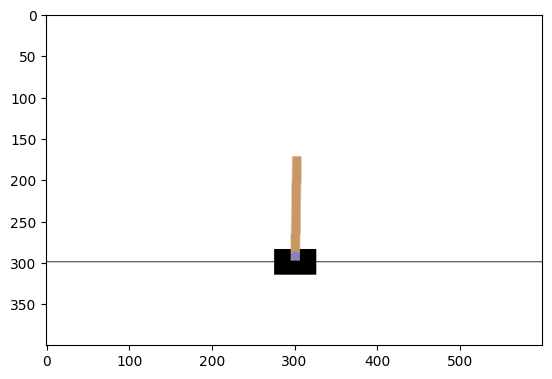

In [3]:
env = gym.make("CartPole-v0", render_mode="rgb_array").env
env.reset()
n_actions = int(env.action_space.n)         # cast np.int64 -> int for keras Dense
state_dim = tuple(int(x) for x in env.observation_space.shape)

plt.imshow(env.render())
env.close()

# Approximate (deep) Q-learning: building the network

To train a neural network policy one must have a neural network policy. Let's build it.


Since we're working with a pre-extracted features (cart positions, angles and velocities), we don't need a complicated network yet. In fact, let's build something like this for starters:

![img](https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/yet_another_week/_resource/qlearning_scheme.png)

For your first run, please only use linear layers (`L.Dense`) and activations. Stuff like batch normalization or dropout may ruin everything if used haphazardly. 

Also please avoid using nonlinearities like sigmoid & tanh: since agent's observations are not normalized, sigmoids might be saturated at initialization. Instead, use non-saturating nonlinearities like ReLU.

Ideally you should start small with maybe 1-2 hidden layers with < 200 neurons and then increase network size if agent doesn't beat the target score.

In [4]:
# We use TF 2.x eager Keras (rather than the original TF1 graph code), which is
# the modern equivalent of this seminar and avoids the dead `compat.v1.keras` path.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

In [5]:
print("TF visible GPUs:", tf.config.list_physical_devices('GPU'))

TF visible GPUs: []


E0000 00:00:1778364981.276115  353842 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [6]:
network = keras.models.Sequential([
    L.Input(shape=state_dim),
    L.Dense(128, activation='relu'),
    L.Dense(128, activation='relu'),
    L.Dense(n_actions, activation='linear'),
])

In [7]:
def get_action(state, epsilon=0):
    """
    sample actions with epsilon-greedy policy
    recap: with p = epsilon pick random action, else pick action with highest Q(s,a)
    """
    q_values = network(np.asarray(state, dtype=np.float32)[None]).numpy()[0]

    if np.random.random() < epsilon:
        return int(np.random.randint(n_actions))
    return int(np.argmax(q_values))

In [8]:
assert network.output_shape == (None, n_actions), "please make sure your model maps state s -> [Q(s,a0), ..., Q(s, a_last)]"
assert network.layers[-1].activation == keras.activations.linear, "please make sure you predict q-values without nonlinearity"

# test epsilon-greedy exploration
s, _ = env.reset()
assert np.shape(get_action(s)) == (), "please return just one action (integer)"
for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed'%eps)

e=0.0 tests passed


e=0.1 tests passed


e=0.5 tests passed


e=1.0 tests passed


### Q-learning via gradient descent

We shall now train our agent's Q-function by minimizing the TD loss:
$$ L = { 1 \over N} \sum_i (Q_{\theta}(s,a) - [r(s,a) + \gamma \cdot max_{a'} Q_{-}(s', a')]) ^2 $$


Where
* $s, a, r, s'$ are current state, action, reward and next state respectively
* $\gamma$ is a discount factor defined two cells above.

The tricky part is with  $Q_{-}(s',a')$. From an engineering standpoint, it's the same as $Q_{\theta}$ - the output of your neural network policy. However, when doing gradient descent, __we won't propagate gradients through it__ to make training more stable (see lectures).

To do so, we shall use `tf.stop_gradient` function which basically says "consider this thing constant when doingbackprop".

In [9]:
# Eager mode: replace placeholders by a single tf.function that takes real tensors.
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
gamma = 0.99

In [10]:
@tf.function
def _td_loss(states, actions, rewards, next_states, is_done):
    """TD-loss in eager mode. is_done must be bool."""
    predicted_qvalues = network(states)                                       # [B, n_actions]
    predicted_qvalues_for_actions = tf.reduce_sum(
        predicted_qvalues * tf.one_hot(actions, n_actions), axis=1)            # [B]

    predicted_next_qvalues = network(next_states)                              # [B, n_actions]
    next_state_values = tf.reduce_max(predicted_next_qvalues, axis=1)          # [B]
    target_qvalues_for_actions = rewards + gamma * next_state_values
    target_qvalues_for_actions = tf.where(is_done, rewards, target_qvalues_for_actions)
    target_qvalues_for_actions = tf.stop_gradient(target_qvalues_for_actions)

    return tf.reduce_mean((predicted_qvalues_for_actions - target_qvalues_for_actions) ** 2)


@tf.function
def train_on_batch(states, actions, rewards, next_states, is_done):
    with tf.GradientTape() as tape:
        loss = _td_loss(states, actions, rewards, next_states, is_done)
    grads = tape.gradient(loss, network.trainable_variables)
    optimizer.apply_gradients(zip(grads, network.trainable_variables))
    return loss

In [11]:
# (everything moved into the tf.function above for eager mode)
pass

In [12]:
# (eager training step is `train_on_batch` defined above)
pass

In [13]:
# Eager-mode sanity check: gradient flows through Q(s,a) but not through the
# bootstrap Q(s',a'), and one optimizer step actually changes the loss.
import gymnasium as _gym_chk
_chk_env = _gym_chk.make("CartPole-v0").env
_s, _ = _chk_env.reset()
_a = _chk_env.action_space.sample()
_ns, _r, _term, _, _ = _chk_env.step(_a)
_chk_env.close()

states = tf.constant([_s], dtype=tf.float32)
next_states = tf.constant([_ns], dtype=tf.float32)
actions = tf.constant([_a], dtype=tf.int32)
rewards = tf.constant([_r], dtype=tf.float32)
is_done = tf.constant([_term], dtype=tf.bool)

with tf.GradientTape() as tape:
    qa = tf.reduce_sum(network(states) * tf.one_hot(actions, n_actions), axis=1)
    target = tf.stop_gradient(rewards + gamma * tf.reduce_max(network(next_states), axis=1))
    loss_dbg = tf.reduce_mean((qa - target) ** 2)
grads_qa  = tape.gradient(loss_dbg, network.trainable_variables)
assert any(g is not None and tf.reduce_any(g != 0) for g in grads_qa), "loss must depend on Q(s,a)"
print("eager TD-loss sanity check passed; loss=", float(loss_dbg))

eager TD-loss sanity check passed; loss= 0.9894410371780396


/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


### Playing the game

In [14]:
# (eager Keras: variables are auto-initialized when used)
pass

In [15]:
def generate_session(env, t_max=1000, epsilon=0, train=False):
    """play env with approximate q-learning agent and train it at the same time"""
    total_reward = 0
    s, _ = env.reset()

    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            train_on_batch(
                tf.constant(np.asarray([s],      dtype=np.float32)),
                tf.constant(np.asarray([a],      dtype=np.int32)),
                tf.constant(np.asarray([r],      dtype=np.float32)),
                tf.constant(np.asarray([next_s], dtype=np.float32)),
                tf.constant(np.asarray([terminated], dtype=bool)),
            )

        total_reward += r
        s = next_s
        if done:
            break

    return total_reward

In [16]:
epsilon = 0.5

In [17]:
for i in range(150):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(30)]
    print("epoch #{}\tmean reward = {:.3f}\tepsilon = {:.3f}".format(i, np.mean(session_rewards), epsilon))

    epsilon *= 0.99
    assert epsilon >= 1e-4, "Make sure epsilon is always nonzero during training"

    if np.mean(session_rewards) > 300:
        print("You Win!")
        break

epoch #0	mean reward = 13.533	epsilon = 0.500


epoch #1	mean reward = 13.600	epsilon = 0.495


epoch #2	mean reward = 13.533	epsilon = 0.490


epoch #3	mean reward = 13.267	epsilon = 0.485


epoch #4	mean reward = 14.433	epsilon = 0.480


...

epoch #61	mean reward = 208.533	epsilon = 0.271


epoch #62	mean reward = 81.433	epsilon = 0.268


epoch #63	mean reward = 150.333	epsilon = 0.265


epoch #64	mean reward = 157.633	epsilon = 0.263


epoch #65	mean reward = 302.800	epsilon = 0.260
You Win!


### How to interpret results


Welcome to the f.. world of deep f...n reinforcement learning. Don't expect agent's reward to smoothly go up. Hope for it to go increase eventually. If it deems you worthy.

Seriously though,
* __ mean reward__ is the average reward per game. For a correct implementation it may stay low for some 10 epochs, then start growing while oscilating insanely and converges by ~50-100 steps depending on the network architecture. 
* If it never reaches target score by the end of for loop, try increasing the number of hidden neurons or look at the epsilon.
* __ epsilon__ - agent's willingness to explore. If you see that agent's already at < 0.01 epsilon before it's is at least 200, just reset it back to 0.1 - 0.5.

### Record videos

As usual, we now use `gym.wrappers.Monitor` to record a video of our agent playing the game. Unlike our previous attempts with state binarization, this time we expect our agent to act ~~(or fail)~~ more smoothly since there's no more binarization error at play.

As you already did with tabular q-learning, we set epsilon=0 for final evaluation to prevent agent from exploring himself to death.

In [18]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with gym.make("CartPole-v0", render_mode="rgb_array") as record_env, RecordVideo(
    record_env, video_folder="videos_tf"
) as env_monitor:
    sessions = [generate_session(env_monitor, epsilon=0, train=False) for _ in range(5)]
print("eval mean reward (eps=0):", float(np.mean(sessions)))

/root/Practical_RL_2026/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /root/Practical_RL_2026/week04_approx_rl/videos_tf folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


eval mean reward (eps=0): 126.6


In [19]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))